<h1>Keystone Analysis</h1>
Jesse Garrido | January 18, 2026<br/>

Data Source:</br>
><p>Event-correlated Outage Dataset in America</br>
>Pacific Northwest Labratory, Department of Energy</br>
>April 25, 2025</br>
><a href="https://catalog.data.gov/dataset/event-correlated-outage-dataset-in-america">https://catalog.data.gov/dataset/event-correlated-outage-dataset-in-america</a></p>

In [250]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Read in data
outages_2023 = pd.read_csv(r'..\data\Outage_Dataset\eaglei_outages_with_events_2023.csv')
#Create DataFrame
df = pd.DataFrame(outages_2023)
df.head()

,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,fips,state,county,start_time,duration,end_time,min_customers,max_customers,mean_customers
0,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1001,Alabama,Autauga,2023-01-12 19:00:00,52.00,2023-01-14 23:00:00,216,6873,1259.716346
1,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1003,Alabama,Baldwin,2023-01-12 15:45:00,1.25,2023-01-12 17:00:00,239,716,340.800000
2,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1003,Alabama,Baldwin,2023-01-12 19:15:00,3.00,2023-01-12 22:15:00,251,1107,557.916667
3,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1007,Alabama,Bibb,2023-01-13 04:00:00,7.25,2023-01-13 11:15:00,430,525,448.827586
4,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,1009,Alabama,Blount,2023-01-12 16:30:00,3.50,2023-01-12 20:00:00,204,778,413.571429


<h3>Data Cleaning & Wrangling:</h3>

>The column "fips" contains a an integer identifier unique to each county where an outage occured, redundant data that is dropped.

In [251]:
#Clean Data
df = df.drop('fips', axis=1)  #Drop redundant county code
df.head()

,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,state,county,start_time,duration,end_time,min_customers,max_customers,mean_customers
0,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Autauga,2023-01-12 19:00:00,52.00,2023-01-14 23:00:00,216,6873,1259.716346
1,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Baldwin,2023-01-12 15:45:00,1.25,2023-01-12 17:00:00,239,716,340.800000
2,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Baldwin,2023-01-12 19:15:00,3.00,2023-01-12 22:15:00,251,1107,557.916667
3,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Bibb,2023-01-13 04:00:00,7.25,2023-01-13 11:15:00,430,525,448.827586
4,Alabama-0,Alabama,2023-01-12 14:00:00,2023-01-13 03:00:00,Severe Weather,Alabama,Blount,2023-01-12 16:30:00,3.50,2023-01-12 20:00:00,204,778,413.571429


>The dataset contains no null values.

In [252]:
df.isnull().sum()

event_id                0
state_event             0
Datetime Event Began    0
Datetime Restoration    0
Event Type              0
state                   0
county                  0
start_time              0
duration                0
end_time                0
min_customers           0
max_customers           0
mean_customers          0
dtype: int64

<h3>Exploratory Data Analysis (EDA)</h3>

>Duration is natively described in hours, a column is added to display the value in days. 

In [253]:
df['Duration(d)'] = round(df['duration']/24,1) 
df.rename(columns={'duration':'Duration(h)'},inplace=True)
df['Duration(d)'].describe().round(1)

count    77341.0
mean         0.3
std          0.6
min          0.0
25%          0.0
50%          0.1
75%          0.2
max          8.1
Name: Duration(d), dtype: float64

>Analysis of the 'Event Type' column benefits from being parsed into four (and not thirty-seven) categories

In [254]:
print(df['Event Type'].describe())
print()
print(df['Event Type'].unique())

count              77341
unique                37
top       Severe Weather
freq               52293
Name: Event Type, dtype: object

['Severe Weather' '- Weather or natural disaster'
 'Actual Physical Attack/Vandalism' 'Transmission Interruption'
 'System Operations' 'Suspicious Activity'
 '- Vandalism - Suspicious activity' '- Vandalism' '- Unknown - Vandalism'
 '- Vandalism - Theft' '- Other' 'Vandalism' '- Fuel supply emergency'
 '- Unknown' '- Theft' '- Theft - Other' 'Cyber Event'
 '- Vandalism\xa0- Theft'
 '- Failure at high voltage substation or switchyard'
 '- Physical attack\xa0- Vandalism\xa0- Suspicious activity'
 '- Suspicious activity' '- Transmission equipment failure'
 '- Threat of physical attack' 'Weather or natural disaster - Other'
 '- Vandalism - Theft - Suspicious activity'
 '- Failure at high voltage substation or switchyard\xa0- Weather or natural disaster'
 '- Theft - Suspicious activity'
 '- Physical attack - Generator loss or failure'
 '- Unknown\xa0- Failure 

>Events are parsed by applying the "str.contains" Pandas function, which performs a regex search for discriminating keywords. The function acts on the (previously unknown to me) Series class.

In [255]:
human_keywords = "attack|suspicious|theft|vandalism|cyber"
system_keywords = "failure|fuel|operations|interruption"
system_exclude_keywords = "attack|unknown|other"
def parse_event(event):
    event = pd.Series(event.lower())
    if event.str.contains("weather").any():
        return "Weather"
    if event.str.contains(human_keywords).any():
        return "Human Intervention"
    if event.str.contains(system_keywords).any() & ~event.str.contains(system_exclude_keywords).any():
        return "System Failure"
    return "Unknown"
df['Event']=df['Event Type'].apply(parse_event)
print(df['Event'].value_counts())


Event
Weather               61341
Human Intervention    10790
System Failure         3375
Unknown                1835
Name: count, dtype: int64


In [256]:
#print(df['Event'].value_counts())
print("\n\nWEATHER:",df[df['Event']=="Weather"]['Event Type'].unique(),
    "\n\nHUMAN INTERVENTION:",df[df['Event']=="Human Intervention"]['Event Type'].unique(),
    "\n\nSYSTEM FAILURES:",df[df['Event']=="System Failure"]['Event Type'].unique(),
    "\n\nUNKNOWN:",df[df['Event']=="Unknown"]['Event Type'].unique())



WEATHER: ['Severe Weather' '- Weather or natural disaster'
 'Weather or natural disaster - Other'
 '- Failure at high voltage substation or switchyard\xa0- Weather or natural disaster'
 '- Weather or natural disaster - Other'] 

HUMAN INTERVENTION: ['Actual Physical Attack/Vandalism' 'Suspicious Activity'
 '- Vandalism - Suspicious activity' '- Vandalism' '- Unknown - Vandalism'
 '- Vandalism - Theft' 'Vandalism' '- Theft' '- Theft - Other'
 'Cyber Event' '- Vandalism\xa0- Theft'
 '- Physical attack\xa0- Vandalism\xa0- Suspicious activity'
 '- Suspicious activity' '- Threat of physical attack'
 '- Vandalism - Theft - Suspicious activity'
 '- Theft - Suspicious activity'
 '- Physical attack - Generator loss or failure'
 '- Physical attack - Vandalism - Suspicious activity' '- Physical attack'
 '- Physical attack - Vandalism - Theft - Suspicious activity'
 '- Physical attack - Other' '- Physical attack\xa0- Vandalism\xa0- Other'
 '- Physical attack\xa0- Vandalism'] 

SYSTEM FAILURES: [

In [257]:
df.describe().round(2)

,Duration(h),min_customers,max_customers,mean_customers,Duration(d)
count,77341.00,77341.00,77341.00,77341.00,77341.00
mean,6.34,531.49,1653.96,913.39,0.26
std,15.46,1111.93,6589.02,2547.77,0.65
min,0.25,200.00,200.00,200.00,0.00
25%,0.50,220.00,285.00,267.20,0.00
50%,1.50,278.00,513.00,430.00,0.10
75%,3.75,474.00,1291.00,863.10,0.20
max,193.25,60581.00,348829.00,289849.33,8.10


The data is grouped by state and normalized as a percent of total count of events and duration captured in the year.

In [258]:
events = df['state'].value_counts()
events_df = pd.DataFrame(events.rename_axis('State').reset_index(name='Event Count'))
sum_events = df['state'].value_counts().sum()
events_pu_df = events_df.copy()
events_pu_df['Events'] = pd.DataFrame(events_df['Event Count'].apply(lambda x: x/sum_events*100))
#events_pu_df = events_pu_df.rename_axis('State').reset_index(name='Event Count NORM')

duration = df.groupby('state')['Duration(h)'].sum()
duration_df = pd.DataFrame(duration.rename_axis('State').reset_index(name='Duration(h)'))
sum_duration = duration_df['Duration(h)'].sum()
duration_pu_df = duration_df.copy()
duration_pu_df['Duration'] = pd.DataFrame(duration_df['Duration(h)'].apply(lambda x:x/sum_duration*100))
duration_pu_df


df['customer-hours']=(df['min_customers']+df['max_customers'])/2*df['Duration(h)']
csthrs = df.groupby('state')['customer-hours'].sum()
csthrs_df = pd.DataFrame(csthrs.rename_axis('State').reset_index(name='customer-hours'))
csthrs_df
sum_csthrs = df['customer-hours'].sum()
csthrs_pu_df = csthrs_df.copy()
csthrs_pu_df['Customer-hours'] = pd.DataFrame(csthrs_df['customer-hours'].apply(lambda x: x/sum_csthrs*100))
#csthrs_pu_df = csthrs_pu_df.rename_axis('State').reset_index(name='Percent of Customer-hours')
csthrs_pu_df

bystate_df=events_pu_df.merge(duration_pu_df)
bystate_df=bystate_df.merge(csthrs_pu_df)
bystate_df

bystate_df2=bystate_df.drop(['Event Count','Duration(h)','customer-hours'],axis=1)
#out_df=out_df.filter(regex='NORM|State',axis=1)
bystate_df2=bystate_df2[bystate_df2['Events']>1]
bystate_df2.set_index('State',inplace=True)
print(bystate_df2)


               Events   Duration  Customer-hours
State                                           
Texas       63.479914  46.638138       67.539567
Kentucky    10.473100  29.949997       11.847593
Michigan     4.932701   9.205880       12.052070
California   4.356034   2.538497        0.906376
Florida      1.753274   0.508189        0.368082
Virginia     1.498558   0.768682        0.232146
Georgia      1.321421   1.178058        0.843864
Maryland     1.215397   0.209914        0.160067
Illinois     1.208932   1.079041        0.441121
Wisconsin    1.000763   1.583915        2.087319


In [259]:
events = df['Event'].value_counts()
events_df = pd.DataFrame(events.rename_axis('Event').reset_index(name='Event Count'))
sum_events = df['Event'].value_counts().sum()
events_pu_df = events_df.copy()
events_pu_df['Events'] = pd.DataFrame(events_df['Event Count'].apply(lambda x: x/sum_events*100))
#events_pu_df = events_pu_df.rename_axis('State').reset_index(name='Event Count NORM')

duration = df.groupby('Event')['Duration(h)'].sum()
duration_df = pd.DataFrame(duration.rename_axis('Event').reset_index(name='Duration(h)'))
sum_duration = duration_df['Duration(h)'].sum()
duration_pu_df = duration_df.copy()
duration_pu_df['Duration'] = pd.DataFrame(duration_df['Duration(h)'].apply(lambda x:x/sum_duration*100))
duration_pu_df


df['customer-hours']=(df['min_customers']+df['max_customers'])/2*df['Duration(h)']
csthrs = df.groupby('Event')['customer-hours'].sum()
csthrs_df = pd.DataFrame(csthrs.rename_axis('Event').reset_index(name='customer-hours'))
csthrs_df
sum_csthrs = df['customer-hours'].sum()
csthrs_pu_df = csthrs_df.copy()
csthrs_pu_df['Customer-hours'] = pd.DataFrame(csthrs_df['customer-hours'].apply(lambda x: x/sum_csthrs*100))
#csthrs_pu_df = csthrs_pu_df.rename_axis('State').reset_index(name='Percent of Customer-hours')
csthrs_pu_df

byevent_df=events_pu_df.merge(duration_pu_df)
byevent_df=byevent_df.merge(csthrs_pu_df)
byevent_df

byevent_df2=byevent_df.drop(['Event Count','Duration(h)','customer-hours'],axis=1)
#out_df=out_df.filter(regex='NORM|State',axis=1)
byevent_df2=byevent_df2[byevent_df2['Events']>1]
byevent_df2.set_index('Event',inplace=True)
print(byevent_df2)


                       Events   Duration  Customer-hours
Event                                                   
Weather             79.312396  92.186221       98.111432
Human Intervention  13.951203   5.445477        1.373910
System Failure       4.363792   1.554394        0.340458
Unknown              2.372610   0.813908        0.174200


<h3>Visualizations</h3>
Where did most outages occur? This graph compares the number and duration of events in states which account for more than 1% of all outage durations.


What events caused the greatest duration and frequency of outages?

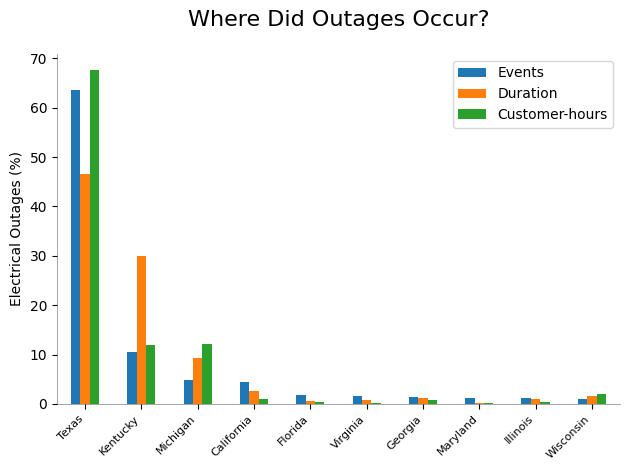

In [ ]:
bystate_df2.plot(kind='bar')
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Electrical Outages (%)")
plt.xlabel("")
plt.title("Where Did Outages Occur?", fontsize=16, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/OutagesPerStateBarPlot.png")
plt.show()

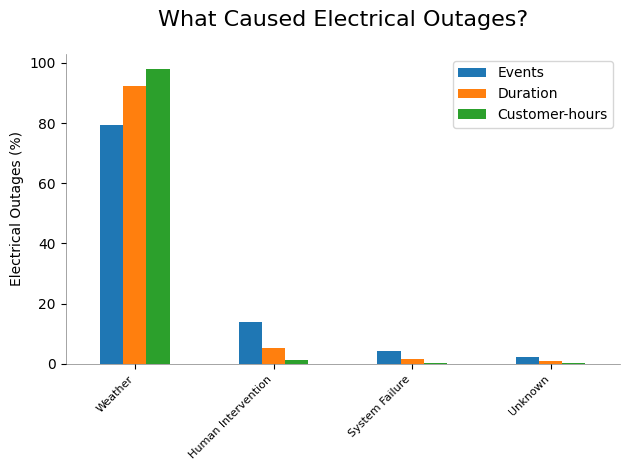

In [ ]:
byevent_df2.plot(kind='bar')
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Electrical Outages (%)")
plt.xlabel("")
plt.title("What Caused Electrical Outages?", fontsize=16, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../plots/OutagesPerEventTypeBarPlot.png")
plt.show()

What events caused outages to occur? This pie chart concludes that Weather accounts for close to 80% of all outage events.

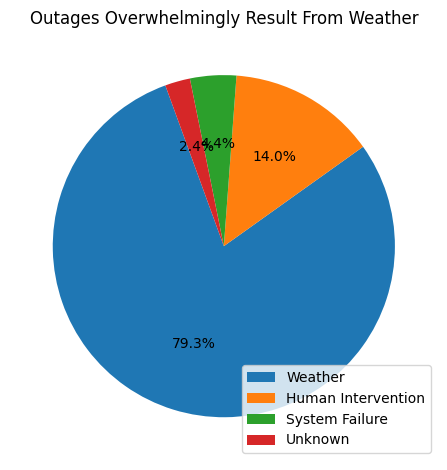

In [ ]:
#plt.figure(figsize=(8,8))
plt.pie(
    byevent_df2['Events'],
    labels=None,
    startangle=110,
    autopct="%1.1f%%",
    #hatch=['**O', 'oO', 'O.O', '.||.'] #uncomment to make beautiful
            )
plt.title("Outages Overwhelmingly Result From Weather")
plt.legend(
    labels = events.index,
    loc="lower right",
)

plt.tight_layout()
plt.show()

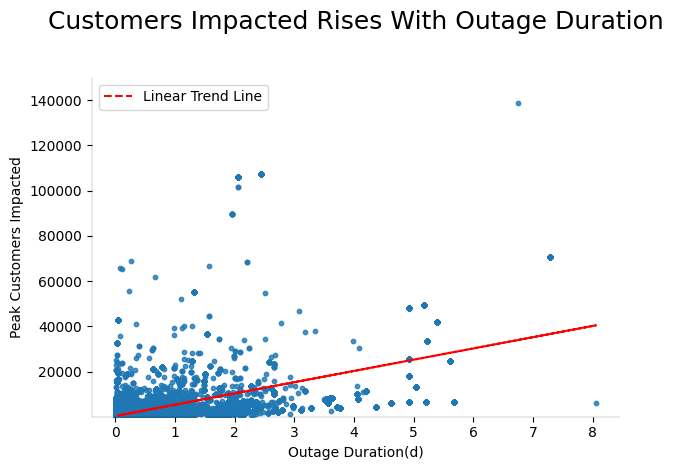

In [270]:
plt.Figure(figsize=(10,6))

#

#colors = ["#18AF75" if genre == featured_genre else "#FFF6F6" for genre in spotify_df["Genre"]] 
# Calculate the best-fit line
x=df["Duration(h)"]/24
y=df["max_customers"]
z = np.polyfit(x,y , 1)
p = np.poly1d(z)
plt.scatter(
            x, 
            y,
            #color = colors,
            alpha = 0.8,
            s = 10
            )
plt.plot(x, p(x), "r--", label="Linear Trend Line")  # 'r--' is for a red dashed line         
plt.ylim(1, 150000)
plt.xlabel("Outage Duration(d)")
plt.ylabel("Peak Customers Impacted")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title("Customers Impacted Rises With Outage Duration", fontsize = 18, pad=35)

for spine in ax.spines.values():
    spine.set_linewidth(0.25)
    spine.set_alpha(0.5)
plt.tight_layout()
plt.savefig("../plots/NumberImpactedVDuration.png")
plt.legend()
plt.show()

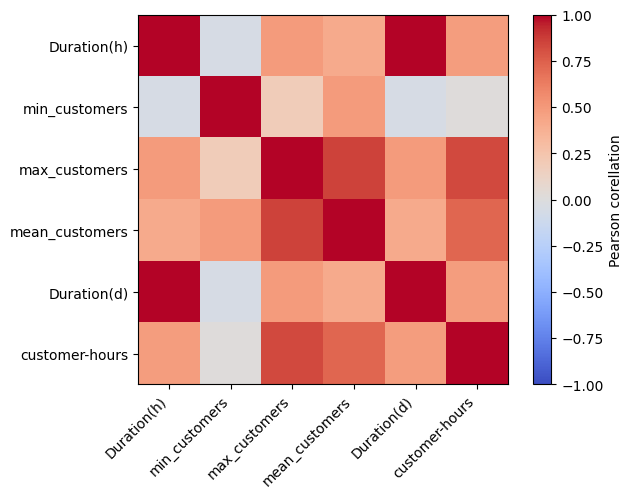

In [264]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

im = plt.imshow(corr, vmin=-1,vmax=1, cmap='coolwarm')
plt.colorbar(im, label="Pearson corellation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.savefig("../plots/Heatmap.png")
plt.show()